In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [4]:

df = pd.read_parquet('data/retail_preprocessed.parquet')


In [5]:
# ============================================================
# 0. 학습 구간 분할 (누수 방지: RFM은 train 구간만 사용)
# ============================================================
CUTOFF = pd.Timestamp('2011-10-31')   # 이후는 test 구간

df_train = df[df['InvoiceDate'] < CUTOFF].copy()

# ============================================================
# 1. RFM 대상 모집단: 회원 + 유효 날짜
# ============================================================
base = df_train[
    df_train['Customer ID'].notna()
    & df_train['InvoiceDate'].notna()
].copy()

print(f"train 전체 행: {len(df_train):,}")
print(f"회원 거래 행: {len(base):,} "
      f"(비회원 제외 {len(df_train) - len(base):,})")

# ============================================================
# 2. Recency / Frequency: 정상 구매만 (전처리 플래그 재사용)
# ============================================================
purchase_df = base[base['is_purchase']].copy()

# 스냅샷은 분할 기준일로 고정 (구매 데이터 마지막 날 X)
snapshot = CUTOFF

rf = (
    purchase_df
    .groupby('Customer ID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda x: (snapshot - x.max()).days
        ),
        Frequency=('Invoice', 'nunique')
    )
)

# ============================================================
# 3. Monetary: 정상 구매 + 취소·반품 합산 순매출
# ============================================================
m = (
    base
    .groupby('Customer ID')
    .agg(Monetary=('Sales', 'sum'))
)

# ============================================================
# 4. 병합 (rf 기준 left join → 취소 전용 고객은 자동 제외)
# ============================================================
rfm = (
    rf
    .join(m, how='left')
    .reset_index()
)

# ============================================================
# 5. 순매출 비양수 고객 처리
# ============================================================
neg = rfm['Monetary'] <= 0
print(f"\n순매출 ≤ 0 고객: {neg.sum():,}명 "
      f"({neg.mean()*100:.2f}%)")
print(f"해당 고객 순매출 합계: {rfm.loc[neg, 'Monetary'].sum():,.0f}")

rfm = rfm[~neg].copy()

print(f"\n최종 RFM 고객 수: {len(rfm):,}")
print(rfm.describe().round(2))

train 전체 행: 910,055
회원 거래 행: 711,094 (비회원 제외 198,961)

순매출 ≤ 0 고객: 13명 (0.23%)
해당 고객 순매출 합계: -1,879

최종 RFM 고객 수: 5,615
       Recency  Frequency   Monetary
count  5615.00    5615.00    5615.00
mean    202.35       5.90    2640.47
std     194.34      11.86   13154.17
min       0.00       1.00       0.00
25%      31.00       1.00     317.40
50%     132.00       3.00     792.15
75%     353.00       6.00    2072.51
max     698.00     329.00  551592.02


In [6]:
rfm['Frequency'].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    5615.000000
mean        5.895102
std        11.863756
min         1.000000
50%         3.000000
90%        12.000000
95%        19.300000
99%        44.000000
99.5%      63.790000
99.9%     161.948000
max       329.000000
Name: Frequency, dtype: float64

In [7]:
rfm.nlargest(
    10, 'Frequency'
)[['Customer ID', 'Recency', 'Frequency', 'Monetary']]

,Customer ID,Recency,Frequency,Monetary
2424,14911,0,329,229201.72
371,12748,4,269,37356.05
2806,15311,2,194,102611.54
696,13089,0,192,100726.49
5206,17841,2,190,57300.84
2138,14606,2,173,27437.35
5214,17850,332,155,50407.77
1706,14156,9,139,290994.15
1263,13694,2,138,182421.12
5452,18102,9,136,551592.02


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Net Monetary가 양수인 고객만 군집화
rfm_all = rfm.copy()

rfm_cluster = rfm_all[
    rfm_all['Monetary'] > 0
].copy()

feature_names = ['Recency', 'Frequency', 'Monetary']

# 로그 변환
rfm_log = rfm_cluster[feature_names].apply(np.log1p)

print("로그 변환 후 왜도")
print(rfm_log.skew())

# 표준화
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=feature_names,
    index=rfm_cluster.index
)

# 식별용으로만 보관
rfm_scaled['Customer ID'] = rfm_cluster['Customer ID']

print("\n표준화 결과")
print(rfm_scaled[feature_names].describe().round(2))

print("\nMonetary 상위 고객")
print(
    rfm_cluster.nlargest(5, 'Monetary')[
        ['Customer ID', 'Recency', 'Frequency', 'Monetary']
    ]
)

로그 변환 후 왜도
Recency     -0.748715
Frequency    1.037739
Monetary     0.182234
dtype: float64

표준화 결과
       Recency  Frequency  Monetary
count  5615.00    5615.00   5615.00
mean     -0.00       0.00      0.00
std       1.00       1.00      1.00
min      -2.97      -1.02     -4.88
25%      -0.70      -1.02     -0.70
50%       0.23      -0.15     -0.04
75%       0.87       0.55      0.66
max       1.31       5.39      4.71

Monetary 상위 고객
     Customer ID  Recency  Frequency   Monetary
5452       18102        9        136  551592.02
2177       14646        3        130  486249.31
1706       14156        9        139  290994.15
2424       14911        0        329  229201.72
4843       17450        6         39  202204.82


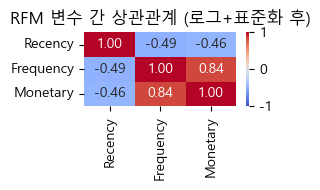

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
sns.heatmap(
    rfm_scaled[feature_names].corr(),
    vmin=-1, vmax=1,          # 음의 상관 표시 필수
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('RFM 변수 간 상관관계 (로그+표준화 후)')
plt.tight_layout()
plt.show()

k=5 부근부터 완만한 감소 구간

k= 2 | inertia=   8459.4 | silhouette=0.4389
k= 3 | inertia=   6432.8 | silhouette=0.3447
k= 4 | inertia=   4829.1 | silhouette=0.3740
k= 5 | inertia=   4061.8 | silhouette=0.3425
k= 6 | inertia=   3562.6 | silhouette=0.3375
k= 7 | inertia=   3204.3 | silhouette=0.2924
k= 8 | inertia=   2919.8 | silhouette=0.2940
k= 9 | inertia=   2702.2 | silhouette=0.2962
k=10 | inertia=   2499.2 | silhouette=0.2838

Elbow 기준 k: 5
Silhouette 기준 k: 2
최종 선택 k: 5


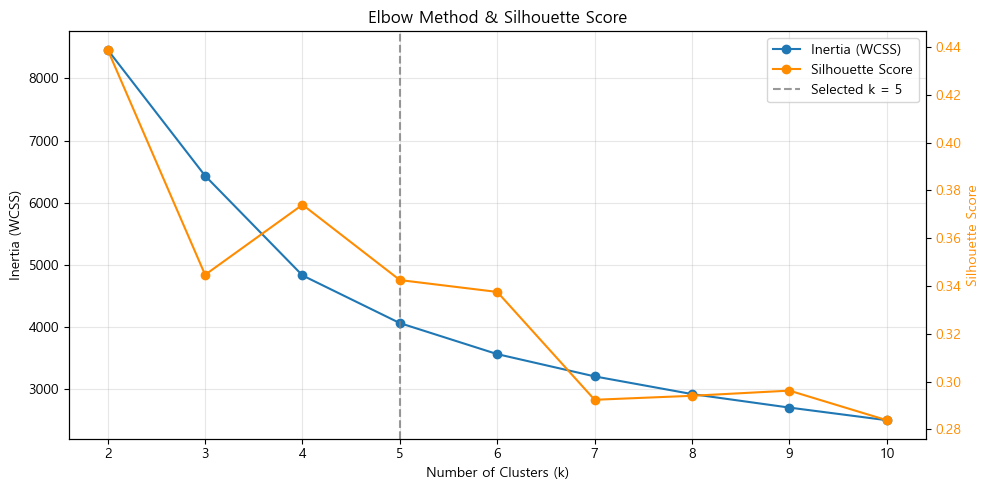

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

X = rfm_scaled[feature_names]
k_range = list(range(2, 11))

inertias = []
silhouettes = []

# =========================
# K별 평가
# =========================
for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X, labels)
    )

    print(
        f"k={k:2d} | "
        f"inertia={km.inertia_:9.1f} | "
        f"silhouette={silhouettes[-1]:.4f}"
    )

# =========================
# Elbow 기준
# =========================
knee = KneeLocator(
    k_range,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = knee.elbow

# =========================
# Silhouette 기준
# =========================
silhouette_k = k_range[np.argmax(silhouettes)]

# =========================
# 최종 k 선택
# =========================
if elbow_k is not None:

    elbow_idx = k_range.index(elbow_k)

    max_sil = max(silhouettes)
    elbow_sil = silhouettes[elbow_idx]

    # Elbow 지점의 실루엣이 최대값의 70% 이상이면 채택
    if elbow_sil >= max_sil * 0.70:
        best_k = elbow_k
    else:
        best_k = silhouette_k

else:
    best_k = silhouette_k


print(f"\nElbow 기준 k: {elbow_k}")
print(f"Silhouette 기준 k: {silhouette_k}")
print(f"최종 선택 k: {best_k}")


# =========================
# 하나의 그래프에 표시
# =========================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow / Inertia
line1 = ax1.plot(
    k_range,
    inertias,
    'o-',
    label='Inertia (WCSS)'
)

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

# 오른쪽 y축 생성
ax2 = ax1.twinx()

# Silhouette - 주황색
line2 = ax2.plot(
    k_range,
    silhouettes,
    'o-',
    color='darkorange',
    label='Silhouette Score'
)

ax2.set_ylabel(
    'Silhouette Score',
    color='darkorange'
)

ax2.tick_params(
    axis='y',
    labelcolor='darkorange'
)

# 최종 선택 k 표시
ax1.axvline(
    best_k,
    linestyle='--',
    color='gray',
    alpha=0.8,
    label=f'Selected k = {best_k}'
)

# 범례 합치기
lines = line1 + line2
labels = [line.get_label() for line in lines]

selected_line = ax1.get_lines()[-1]
lines.append(selected_line)
labels.append(selected_line.get_label())

ax1.legend(
    lines,
    labels,
    loc='best'
)

plt.title('Elbow Method & Silhouette Score')
plt.tight_layout()
plt.show()

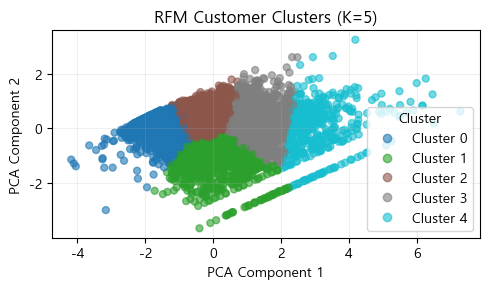

PCA 설명분산: [0.738 0.209]
누적 설명분산: 0.948


In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. 최적 k로 KMeans 학습
# =========================
kmeans = KMeans(
    n_clusters=best_k,   # 앞에서 선택된 best_k = 5
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# RFM 데이터에 군집 번호 저장
rfm_cluster['cluster_5'] = labels


# =========================
# 2. PCA로 RFM 3차원 → 2차원 축소
# =========================
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# =========================
# 3. 산점도
# =========================
plt.figure(figsize=(5, 3))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'RFM Customer Clusters (K={best_k})')

plt.legend(
    scatter.legend_elements()[0],
    [f'Cluster {i}' for i in range(best_k)],
    title='Cluster'
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# PCA가 원래 RFM 정보를 얼마나 설명하는지
print(
    'PCA 설명분산:',
    pca.explained_variance_ratio_.round(3)
)

print(
    '누적 설명분산:',
    pca.explained_variance_ratio_.sum().round(3)
)

# PC1은 Frequency와 Monetary가 높고 Recency가 낮을수록 증가하므로, 고객의 종합적인 구매가치·활성도를 나타내는 축으로 해석

In [12]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

print(loadings)

                PC1       PC2
Recency   -0.484606  0.874058
Frequency  0.621805  0.316613
Monetary   0.615236  0.368481


In [13]:
rfm_compare = rfm_cluster.copy()

for k in [4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    rfm_compare[f'cluster_{k}'] = km.fit_predict(X)

    profile = (
        rfm_compare
        .groupby(f'cluster_{k}')
        .agg(
            고객수=('Customer ID', 'count'),
            R=('Recency', 'mean'),
            F=('Frequency', 'mean'),
            M=('Monetary', 'mean')
        )
        .round(1)
    )

    print(f"\n=== k={k} ===")
    print(profile.sort_values('M', ascending=False))


=== k=4 ===
            고객수      R     F        M
cluster_4                            
2          1017   32.6  19.3  10387.3
1          1494  212.0   5.1   1809.4
3          1052   23.0   2.8    857.4
0          2052  371.4   1.4    320.3

=== k=5 ===
            고객수      R     F        M
cluster_5                            
4           452   17.5  29.5  17801.3
3          1160   72.1   9.0   3508.8
2          1408  275.9   3.5   1134.0
1           940   22.8   2.5    748.8
0          1655  383.5   1.2    247.3


In [14]:
print(df_train.loc[df_train['Quantity'] > 20000, 
                   ['Invoice','StockCode','Quantity','InvoiceDate','Customer ID']])

       Invoice StockCode  Quantity         InvoiceDate Customer ID
550441  541431     23166     74215 2011-01-18 10:01:00       12346


,Recency,Frequency,Monetary
cluster_5,,,
0,0.834,-0.904,-1.030
1,-1.134,-0.417,-0.276
2,0.611,-0.091,0.088
3,-0.431,0.918,0.902
4,-1.492,2.102,1.758


cluster_5
0    1655
1     940
2    1408
3    1160
4     452
Name: count, dtype: int64


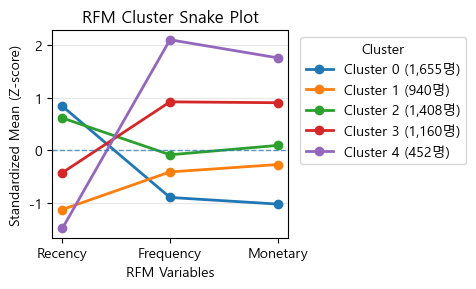

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 표준화된 RFM 데이터에 Customer ID 추가
# ==========================================

snake_df = rfm_scaled[feature_names].copy()
snake_df['Customer ID'] = rfm_cluster['Customer ID'].values

# ==========================================
# 2. Customer ID 기준으로 cluster_5 병합
# ==========================================

snake_df = snake_df.merge(
    rfm_cluster[['Customer ID', 'cluster_5']],
    on='Customer ID',
    how='left',
    validate='one_to_one'
)

# 병합 이상 여부 확인
assert snake_df['cluster_5'].notna().all(), \
    "일부 Customer ID에 cluster가 매칭되지 않았습니다."

# ==========================================
# 3. 클러스터별 표준화 RFM 평균
# ==========================================

snake_mean = (
    snake_df
    .groupby('cluster_5')[feature_names]
    .mean()
)

display(snake_mean.round(3))


# ==========================================
# 4. 클러스터별 고객 수
# ==========================================

cluster_counts = (
    snake_df['cluster_5']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


# ==========================================
# 5. Snake Plot
# ==========================================

plt.figure(figsize=(5, 3))

x = range(len(feature_names))

for cluster in snake_mean.index:

    values = snake_mean.loc[cluster, feature_names]
    n = cluster_counts.loc[cluster]

    plt.plot(
        x,
        values,
        marker='o',
        linewidth=2,
        label=f'Cluster {cluster} ({n:,}명)'
    )

# 표준화 평균 기준선
plt.axhline(
    0,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

plt.xticks(
    x,
    feature_names
)

plt.ylabel('Standardized Mean (Z-score)')
plt.xlabel('RFM Variables')
plt.title('RFM Cluster Snake Plot')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [16]:
cluster_name_map = {
    0: 'Lost',
    1: 'New / Promising',
    2: 'Loyal',
    3: 'Champions',
    4: 'At Risk'
}

rfm_cluster['Segment'] = rfm_cluster['cluster_5'].map(cluster_name_map)

In [17]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 0. 기본 설정
# ============================================================
N_CLUSTERS = 5
RANDOM_STATE = 42
EPSILON = 1e-8

required_cols = [
    'Invoice',
    'InvoiceDate',
    'Customer ID',
    'Quantity',
    'Price',
    'Sales'
]

missing_cols = [
    col for col in required_cols
    if col not in df_train.columns
]

if missing_cols:
    raise ValueError(
        f"df_train에 필요한 칼럼이 없습니다: {missing_cols}"
    )


# ============================================================
# 1. 거래 데이터 준비
# ============================================================
tx = df_train[required_cols].copy()

tx['Invoice'] = (
    tx['Invoice']
    .astype(str)
    .str.strip()
)

tx['InvoiceDate'] = pd.to_datetime(
    tx['InvoiceDate'],
    errors='coerce'
)

tx['Quantity'] = pd.to_numeric(
    tx['Quantity'],
    errors='coerce'
)

tx['Price'] = pd.to_numeric(
    tx['Price'],
    errors='coerce'
)

tx['Sales'] = pd.to_numeric(
    tx['Sales'],
    errors='coerce'
)

tx = tx.dropna(
    subset=[
        'InvoiceDate',
        'Customer ID',
        'Quantity',
        'Price',
        'Sales'
    ]
).copy()

# 고객 ID 표현 통일
tx['Customer ID'] = (
    tx['Customer ID']
    .astype(str)
)

# 월 단위
tx['YearMonth'] = (
    tx['InvoiceDate']
    .dt.to_period('M')
)

# 정상 구매 여부
tx['is_purchase'] = (
    ~tx['Invoice'].str.startswith('C')
    & (tx['Quantity'] > 0)
)

print("거래 데이터 준비 완료")
print("거래 행 수:", len(tx))
print("고객 수:", tx['Customer ID'].nunique())
print(
    "기간:",
    tx['InvoiceDate'].min(),
    "~",
    tx['InvoiceDate'].max()
)


# ============================================================
# 2. 고객 × 월 순매출 및 순수량 집계
# ============================================================
monthly_net = (
    tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_sales=('Sales', 'sum'),
        monthly_quantity=('Quantity', 'sum')
    )
)

# 화폐 및 수량 계산 오차 정리
monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .round(2)
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .round(6)
)

monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .mask(
        monthly_net['monthly_sales'].abs() < EPSILON,
        0
    )
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .mask(
        monthly_net['monthly_quantity'].abs() < EPSILON,
        0
    )
)


# ============================================================
# 3. 정상 구매 기준 월별 주문 횟수와 마지막 구매일
# ============================================================
purchase_tx = tx[
    tx['is_purchase']
].copy()

if purchase_tx.empty:
    raise ValueError(
        "정상 구매 거래가 없습니다."
    )

monthly_purchase = (
    purchase_tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_orders=('Invoice', 'nunique'),
        monthly_last_purchase=('InvoiceDate', 'max')
    )
)

monthly = monthly_net.merge(
    monthly_purchase,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

monthly['monthly_orders'] = (
    monthly['monthly_orders']
    .fillna(0)
    .astype(int)
)


# ============================================================
# 4. 고객별 최초 구매월부터 마지막 관측월까지 패널 생성
# ============================================================
first_purchase_month = (
    purchase_tx
    .groupby('Customer ID')['YearMonth']
    .min()
)

last_observed_month = (
    tx['YearMonth']
    .max()
)

panel_parts = []

for customer_id, start_month in first_purchase_month.items():

    customer_months = pd.period_range(
        start=start_month,
        end=last_observed_month,
        freq='M'
    )

    customer_panel = pd.DataFrame({
        'Customer ID': customer_id,
        'YearMonth': customer_months
    })

    panel_parts.append(customer_panel)

panel = pd.concat(
    panel_parts,
    ignore_index=True
)

panel = panel.merge(
    monthly,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

fill_zero_cols = [
    'monthly_sales',
    'monthly_quantity',
    'monthly_orders'
]

panel[fill_zero_cols] = (
    panel[fill_zero_cols]
    .fillna(0)
)

panel['monthly_sales'] = (
    panel['monthly_sales']
    .round(2)
)

panel['monthly_quantity'] = (
    panel['monthly_quantity']
    .round(6)
)

panel['monthly_orders'] = (
    panel['monthly_orders']
    .astype(int)
)

panel = (
    panel
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. Recency 계산
# ============================================================
panel['last_purchase_date'] = (
    panel
    .groupby('Customer ID')[
        'monthly_last_purchase'
    ]
    .ffill()
)

# 날짜와 시간을 날짜 단위로 통일
panel['last_purchase_date'] = (
    pd.to_datetime(
        panel['last_purchase_date'],
        errors='coerce'
    )
    .dt.normalize()
)

panel['month_end'] = (
    panel['YearMonth']
    .dt.to_timestamp(how='end')
    .dt.normalize()
)

panel['Recency'] = (
    panel['month_end']
    - panel['last_purchase_date']
).dt.days

negative_recency_count = (
    panel['Recency']
    .dropna()
    .lt(0)
    .sum()
)

if negative_recency_count > 0:
    raise ValueError(
        f"음수 Recency가 {negative_recency_count}건 있습니다."
    )


# ============================================================
# 6. 누적 Frequency 및 Monetary 계산
# ============================================================
panel['Frequency'] = (
    panel
    .groupby('Customer ID')[
        'monthly_orders'
    ]
    .cumsum()
)

panel['Monetary'] = (
    panel
    .groupby('Customer ID')[
        'monthly_sales'
    ]
    .cumsum()
    .round(2)
)

# 사실상 0인 부동소수점 오차 제거
panel['Monetary'] = (
    panel['Monetary']
    .mask(
        panel['Monetary'].abs() < EPSILON,
        0
    )
)

print("\nMonetary 최소값:")
print(panel['Monetary'].min())

print(
    "사실상 0인 Monetary 수:",
    (panel['Monetary'].abs() < EPSILON).sum()
)


# ============================================================
# 7. 월별 행동 변수 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

# YearMonth가 2010-06일 경우:
# lag_1 = 2010-06
# lag_2 = 2010-05
# lag_3 = 2010-04

panel['sales_lag_1'] = (
    panel['monthly_sales']
)

panel['sales_lag_2'] = (
    customer_group['monthly_sales']
    .shift(1)
)

panel['sales_lag_3'] = (
    customer_group['monthly_sales']
    .shift(2)
)

panel['orders_lag_1'] = (
    panel['monthly_orders']
)

panel['orders_lag_2'] = (
    customer_group['monthly_orders']
    .shift(1)
)

panel['orders_lag_3'] = (
    customer_group['monthly_orders']
    .shift(2)
)

panel['quantity_lag_1'] = (
    panel['monthly_quantity']
)


# ============================================================
# 8. 고객 활동 기간과 계절 변수
# ============================================================
panel['first_purchase_month'] = (
    panel
    .groupby('Customer ID')[
        'YearMonth'
    ]
    .transform('min')
)

panel['customer_tenure'] = (
    (
        panel['YearMonth'].dt.year
        - panel['first_purchase_month'].dt.year
    ) * 12
    +
    (
        panel['YearMonth'].dt.month
        - panel['first_purchase_month'].dt.month
    )
)

panel['month'] = (
    panel['YearMonth']
    .dt.month
)


# ============================================================
# 9. 다음 달 타깃 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

panel['target_next_sales'] = (
    customer_group['monthly_sales']
    .shift(-1)
)

panel['next_month_orders'] = (
    customer_group['monthly_orders']
    .shift(-1)
)

panel['target_next_purchase'] = np.where(
    panel['next_month_orders'].isna(),
    np.nan,
    (
        panel['next_month_orders'] > 0
    ).astype(int)
)

# 다음 달 정답이 없는 마지막 관측월 제거
panel_model = panel[
    panel['target_next_sales'].notna()
].copy()

panel_model['target_next_sales'] = (
    panel_model['target_next_sales']
    .round(2)
)

panel_model['target_next_purchase'] = (
    panel_model['target_next_purchase']
    .astype(int)
)


# ============================================================
# 10. RFM 군집화 대상 생성
# ============================================================
segment_features = [
    'Recency',
    'Frequency',
    'Monetary'
]

segment_mask = (
    panel_model[segment_features]
    .notna()
    .all(axis=1)
    & (panel_model['Recency'] >= 0)
    & (panel_model['Frequency'] > 0)
    & (panel_model['Monetary'] > EPSILON)
)

segment_data = (
    panel_model
    .loc[
        segment_mask,
        segment_features
    ]
    .astype(float)
    .copy()
)

if len(segment_data) < N_CLUSTERS:
    raise ValueError(
        "군집화할 고객-월 데이터가 너무 적습니다."
    )

print("\nRFM 군집화 대상")
print("대상 행 수:", len(segment_data))
print(segment_data.describe().round(2))


# ============================================================
# 11. 로그 변환 및 유한값 검증
# ============================================================
segment_log = np.log1p(
    segment_data
)

segment_array = (
    segment_log
    .to_numpy(dtype=float)
)

is_finite = np.isfinite(
    segment_array
).all(axis=1)

if not is_finite.all():

    bad_rows = (
        segment_log
        .loc[~is_finite]
    )

    print("\n로그 변환 이상 행")
    print(bad_rows.head(20))

    raise ValueError(
        "RFM 로그 데이터에 NaN 또는 무한값이 있습니다."
    )

print("\n로그 변환 후 왜도")
print(segment_log.skew())


# ============================================================
# 12. 표준화 및 K-means 군집화
# ============================================================
segment_scaler = StandardScaler()

segment_scaled = (
    segment_scaler
    .fit_transform(segment_log)
)

segment_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10
)

segment_labels = (
    segment_kmeans
    .fit_predict(segment_scaled)
)

panel_model['cluster_5'] = pd.Series(
    pd.NA,
    index=panel_model.index,
    dtype='Int64'
)

panel_model.loc[
    segment_mask,
    'cluster_5'
] = segment_labels


# ============================================================
# 13. 군집 프로필 출력
# ============================================================
segment_profile = (
    panel_model
    .dropna(subset=['cluster_5'])
    .groupby('cluster_5')
    .agg(
        고객월수=('Customer ID', 'size'),
        고유고객수=('Customer ID', 'nunique'),
        R=('Recency', 'mean'),
        F=('Frequency', 'mean'),
        M=('Monetary', 'mean')
    )
    .round(1)
    .sort_values(
        'M',
        ascending=False
    )
)

print("\n=== 월별 RFM 군집 프로필 ===")
print(segment_profile)

거래 데이터 준비 완료
거래 행 수: 711094
고객 수: 5651
기간: 2009-12-01 07:45:00 ~ 2011-10-30 16:17:00

Monetary 최소값:
-1663.06
사실상 0인 Monetary 수: 207

RFM 군집화 대상
대상 행 수: 80408
        Recency  Frequency   Monetary
count  80408.00   80408.00   80408.00
mean     126.36       4.42    1956.34
std      129.75       8.50    9055.77
min        0.00       1.00       1.15
25%       27.00       1.00     285.34
50%       79.00       2.00     630.77
75%      188.00       5.00    1572.86
max      668.00     306.00  498910.75

로그 변환 후 왜도
Recency     -0.707428
Frequency    1.274313
Monetary     0.283716
dtype: float64

=== 월별 RFM 군집 프로필 ===
            고객월수  고유고객수      R     F        M
cluster_5                                    
3           5704    905   17.3  23.1  13982.8
4          15008   2151   56.6   7.1   2797.0
2          20086   2878  168.9   2.9   1036.8
1          14192   5276   18.7   2.0    612.3
0          25418   3196  218.6   1.2    238.2


In [18]:
# ============================================================
# 14. 군집 번호에 세그먼트 이름 부여
# ============================================================
panel_cluster_name_map = {
    0: 'Champions',
    3: 'Loyal',
    2: 'New / Promising',
    1: 'At Risk',
    4: 'Lost'
}

panel_model['Segment'] = panel_model['cluster_5'].map(panel_cluster_name_map)

# 라벨 자동검증 (다음에 라벨 또 바뀌면 여기서 에러남)
prof = (panel_model.dropna(subset=['cluster_5'])
        .groupby('cluster_5')[['Recency','Frequency','Monetary']].mean())
assert panel_cluster_name_map[prof['Monetary'].idxmax()] == 'Champions'
assert panel_cluster_name_map[prof['Recency'].idxmax()] == 'Lost'

print("\n=== 세그먼트 분포 ===")
print(panel_model['Segment'].value_counts(dropna=False))

AssertionError: 

In [ ]:
nan_rows = panel_model[
    panel_model['Segment'].isna()
].copy()

print("NaN 행 수:", len(nan_rows))

print(
    nan_rows[
        ['Recency', 'Frequency', 'Monetary']
    ].describe()
)

print("\n제외 원인")
print({
    'Recency 결측': nan_rows['Recency'].isna().sum(),
    'Recency 음수': (nan_rows['Recency'] < 0).sum(),
    'Frequency 0 이하': (nan_rows['Frequency'] <= 0).sum(),
    'Monetary 0 이하': (nan_rows['Monetary'] <= EPSILON).sum()
})

NaN 행 수: 259
          Recency   Frequency     Monetary
count  259.000000  259.000000   259.000000
mean   195.169884    1.281853  -181.635560
std    149.776067    0.763572   468.862026
min      0.000000    1.000000 -1663.060000
25%     75.000000    1.000000     0.000000
50%    165.000000    1.000000     0.000000
75%    286.500000    1.000000     0.000000
max    668.000000    4.000000     0.000000

제외 원인
{'Recency 결측': np.int64(0), 'Recency 음수': np.int64(0), 'Frequency 0 이하': np.int64(0), 'Monetary 0 이하': np.int64(259)}


In [ ]:
# ============================================================
# 15. 최종 CSV 생성
# ============================================================
export_cols = [
    'Customer ID',
    'YearMonth',
    'Recency',
    'Frequency',
    'Monetary',
    'Segment',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'orders_lag_1',
    'orders_lag_2',
    'orders_lag_3',
    'quantity_lag_1',
    'customer_tenure',
    'month',
    'target_next_sales',
    'target_next_purchase'
]

customer_month_panel = (
    panel_model[export_cols]
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
    .copy()
)

lag_cols = [
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'orders_lag_1',
    'orders_lag_2',
    'orders_lag_3',
    'quantity_lag_1'
]

customer_month_panel[lag_cols] = (
    customer_month_panel[lag_cols]
    .fillna(0)
)

# 금액 변수 반올림
money_cols = [
    'Monetary',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'target_next_sales'
]

customer_month_panel[money_cols] = (
    customer_month_panel[money_cols]
    .round(2)
)

# 수량 반올림
customer_month_panel['quantity_lag_1'] = (
    customer_month_panel['quantity_lag_1']
    .round(6)
)

# 군집화되지 않은 Monetary <= 0 고객-월 제외
customer_month_panel = (
    customer_month_panel
    .dropna(subset=['Segment'])
    .reset_index(drop=True)
)

# CSV 호환을 위해 문자열 변환
customer_month_panel['YearMonth'] = (
    customer_month_panel['YearMonth']
    .astype(str)
)

output_path = 'customer_month_rfm_panel.csv'

customer_month_panel.to_csv(
    output_path,
    index=False,
    encoding='utf-8-sig'
)

print("\n저장 완료:", output_path)
print("최종 행 수:", len(customer_month_panel))
print(
    "고객 수:",
    customer_month_panel[
        'Customer ID'
    ].nunique()
)
print(
    "기간:",
    customer_month_panel[
        'YearMonth'
    ].min(),
    "~",
    customer_month_panel[
        'YearMonth'
    ].max()
)

print("\n세그먼트 분포")
print(
    customer_month_panel[
        'Segment'
    ].value_counts()
)

print("\n다음 달 구매 여부 분포")
print(
    customer_month_panel[
        'target_next_purchase'
    ].value_counts()
)

print("\n최종 데이터 미리보기")
print(customer_month_panel.head(10))


저장 완료: customer_month_rfm_panel.csv
최종 행 수: 80408
고객 수: 5406
기간: 2009-12 ~ 2011-09

세그먼트 분포
Segment
At Risk            25473
Lost               20062
Champions          15082
New / Promising    14224
Loyal               5567
Name: count, dtype: int64

다음 달 구매 여부 분포
target_next_purchase
0    62870
1    17538
Name: count, dtype: int64

최종 데이터 미리보기
  Customer ID YearMonth  Recency  Frequency  Monetary          Segment  \
0       12346   2010-03       29          1     27.05          At Risk   
1       12346   2010-04       59          1     27.05          At Risk   
2       12346   2010-05       90          1     27.05          At Risk   
3       12346   2010-06        2          2    169.36  New / Promising   
4       12346   2010-07       33          2    169.36  New / Promising   
5       12346   2010-08       64          2    169.36          At Risk   
6       12346   2010-09       94          2    169.36          At Risk   
7       12346   2010-10      125          2    169.36      

In [ ]:
print("\n결측값 개수")
print(customer_month_panel.isna().sum())

print("\n중복 고객-월 수")
print(
    customer_month_panel.duplicated(
        subset=['Customer ID', 'YearMonth']
    ).sum()
)

print("\n무한값 수")
numeric_cols = customer_month_panel.select_dtypes(
    include='number'
).columns

print(
    np.isinf(
        customer_month_panel[numeric_cols]
        .to_numpy(dtype=float)
    ).sum()
)


결측값 개수
Customer ID             0
YearMonth               0
Recency                 0
Frequency               0
Monetary                0
Segment                 0
sales_lag_1             0
sales_lag_2             0
sales_lag_3             0
orders_lag_1            0
orders_lag_2            0
orders_lag_3            0
quantity_lag_1          0
customer_tenure         0
month                   0
target_next_sales       0
target_next_purchase    0
dtype: int64

중복 고객-월 수
0

무한값 수
0


In [ ]:
tmp = tx.copy()
tmp['first_pm'] = tmp['Customer ID'].map(first_purchase_month)

no_purchase = tmp['first_pm'].isna()                    # 구매 없이 취소만 있는 고객
before_first = ~no_purchase & (tmp['YearMonth'] < tmp['first_pm'])

print('구매이력 없는 고객:', round(tmp.loc[no_purchase,'Sales'].sum(),2),
      '| 고객수', tmp.loc[no_purchase,'Customer ID'].nunique())
print('첫구매 이전 취소:', round(tmp.loc[before_first,'Sales'].sum(),2))
print('합계:', round(tmp.loc[no_purchase|before_first,'Sales'].sum(),2))
# 구매 이력이 없는 취소 전용 고객 23명과 첫 구매월 이전 반품 건은 패널에서 제외했으며, 이는 전체 순매출의 0.03% 수준이다.

구매이력 없는 고객: -1406.13 | 고객수 23
첫구매 이전 취소: -3325.17
합계: -4731.3
